Enclosed Energy Notebook
========================

This notebook demonstrates how to use the OpenCSP SpotAnalysis framework to process a target image and plot the enclosed energy. Features of this notebook are:

1. Average many images.
2. Subtract a null (non-sun) image from an illuminated (on-sun) image.
3. Find the center of a spot using one of several methods.
4. Create plots for false color, moments (centroid), and cross section.
5. Create an enclosed energy plot.
6. Generate a powerpoint deck for this example.

In [1]:
%load_ext autoreload
%autoreload 2  

In [2]:
import configparser
import cv2 as cv
import numpy as np
import os
import PIL.Image as Image

from opencsp import opencsp_settings
import contrib.common.lib.cv.annotations.MomentsAnnotation as manno
import opencsp.common.lib.cv.annotations.HotspotAnnotation as hanno
from contrib.common.lib.cv.spot_analysis.image_processor import *
from opencsp.common.lib.cv.spot_analysis.image_processor import *
import opencsp.common.lib.cv.spot_analysis.SpotAnalysisOperable as sao
import opencsp.common.lib.cv.SpotAnalysis as sa
import opencsp.common.lib.opencsp_path.opencsp_root_path as orp
import opencsp.common.lib.tool.file_tools as ft
import opencsp.common.lib.tool.image_tools as it
import contrib.common.lib.tool.ImageGrid as ig
import opencsp.common.lib.render.Color as clr



Data Paths
----------

To execute other data, or the same data from another location, copy and rename enclosed_energy_settings_ctemp.ini and update the paths to match where the data is located on your computer.

In [3]:
experiment_settings_file = r"C:\ctemp\OpenCSP_example_data\enclosed_energy\input\enclosed_energy_settings_ctemp.ini"
if not ft.file_exists(experiment_settings_file):
    raise FileNotFoundError("File '" + experiment_settings_file + "' does not exist.")

experiment_settings = configparser.ConfigParser()
experiment_settings.read(experiment_settings_file)

nosun_dir = experiment_settings["Default"]["nosun_dir"]
onsun_dir = experiment_settings["Default"]["onsun_dir"]
nosun_images_range = experiment_settings["Default"]["nosun_images_range"].split(",")
onsun_images_range = experiment_settings["Default"]["onsun_images_range"].split(",")

output_dir = experiment_settings["Default"]["output_dir"]

source_img_desc = experiment_settings["Default"]["source_image_desc"]

# Echo input information.
print('nosun_dir = ', nosun_dir)
print('onsun_dir = ', onsun_dir)
print('nosun_images_range = ', nosun_images_range)
print('onsun_images_range = ', onsun_images_range)

print('output_dir = ', output_dir)

print('source_img_desc = ', source_img_desc)

nosun_dir =  C:\ctemp\OpenCSP_example_data\enclosed_energy\input\HeliostatsSpotSize\2_Data\0900_NoSun\PixelData_Images
onsun_dir =  C:\ctemp\OpenCSP_example_data\enclosed_energy\input\HeliostatsSpotSize\2_Data\0900_OnSun\PixelData_Images
nosun_images_range =  ['20241123_090715.90_1123_0900_NoSun_Raw.png', '20241123_090721.58_1123_0900_NoSun_Raw.png']
onsun_images_range =  ['20241123_090823.13_1123_0900_SF_Raw.png', '20241123_090823.68_1123_0900_SF_Raw.png']
output_dir =  C:\ctemp\OpenCSP_example_data\enclosed_energy\output\HeliostatsSpotSize\3_Post
source_img_desc =  Single_NSTTF_Facet_0900


Data Processing
---------------

Everything above this line is set up, and everything below this line is analysis.

The following cell locates images from the directories specified in `experiment_settings.ini`.

In [4]:
def get_images_in_range(dir: str, start_image: str, end_image: str) -> list[str]:
    """Get the path/name.ext for all images in the given directory between the start_image and end_image, inclusively."""
    image_name_exts = it.image_files_in_directory(dir)
    # # Report images found.
    # print("image_name_exts:")
    # for image_name_ext in image_name_exts:
    #     print("    ", image_name_ext)
    # Lookup start and end images.
    start_idx = image_name_exts.index(start_image)
    end_idx = image_name_exts.index(end_image)

    selected_image_name_exts = image_name_exts[start_idx : end_idx + 1]
    selected_images = [ft.join(dir, ne) for ne in selected_image_name_exts]

    return selected_images

print(nosun_dir)
nosun_images = get_images_in_range(nosun_dir, nosun_images_range[0], nosun_images_range[1])
onsun_images = get_images_in_range(onsun_dir, onsun_images_range[0], onsun_images_range[1])
print(f"{len(nosun_images)=}")
print(f"{len(onsun_images)=}")

C:\ctemp\OpenCSP_example_data\enclosed_energy\input\HeliostatsSpotSize\2_Data\0900_NoSun\PixelData_Images
len(nosun_images)=12
len(onsun_images)=2


Average and blur the input images.

Averaging reduces the camera noise floor. Blurring the images reduces the camera shake and atmospheric distortion noise floor. 

Processing image 20241123_090715.90_1123_0900_NoSun_Raw.png
Processing image 20241123_090716.40_1123_0900_NoSun_Raw.png
Processing image 20241123_090716.93_1123_0900_NoSun_Raw.png
Processing image 20241123_090717.43_1123_0900_NoSun_Raw.png
Processing image 20241123_090717.96_1123_0900_NoSun_Raw.png
Processing image 20241123_090718.51_1123_0900_NoSun_Raw.png
Processing image 20241123_090719.03_1123_0900_NoSun_Raw.png
Processing image 20241123_090719.52_1123_0900_NoSun_Raw.png
Processing image 20241123_090720.04_1123_0900_NoSun_Raw.png
Processing image 20241123_090720.54_1123_0900_NoSun_Raw.png
Processing image 20241123_090721.06_1123_0900_NoSun_Raw.png
Processing image 20241123_090721.58_1123_0900_NoSun_Raw.png
In AverageByGroupImageProcessor._execute_aggregate(): averaging 12 images
Processing image 20241123_090823.13_1123_0900_SF_Raw.png
Processing image 20241123_090823.68_1123_0900_SF_Raw.png
In AverageByGroupImageProcessor._execute_aggregate(): averaging 2 images

Left: average and 

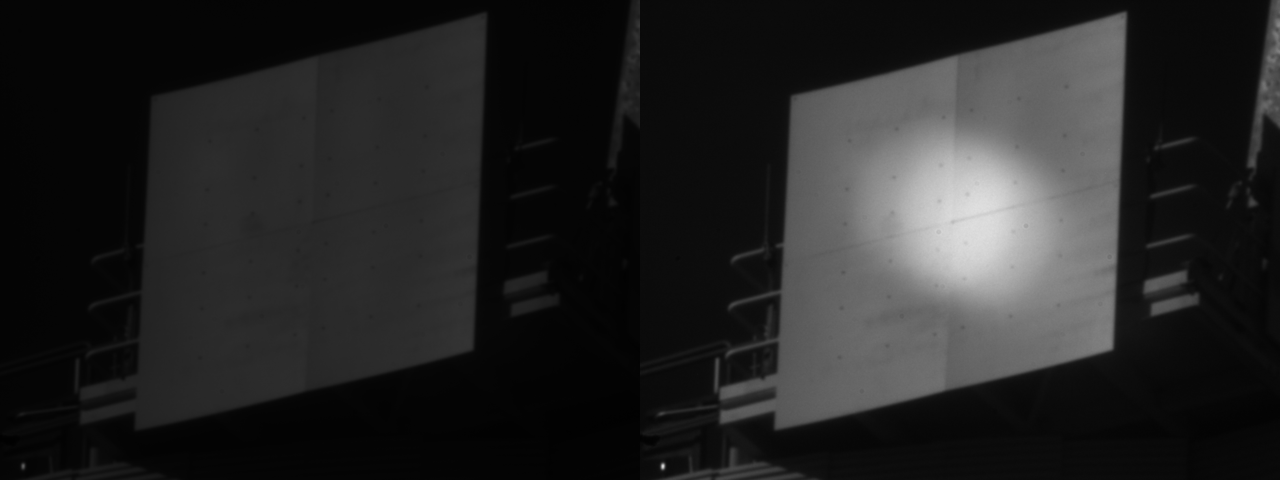

In [5]:
def build_preprocessing_pipeline(input_images: list) -> sa.SpotAnalysis:
    # Define the image processors, including the order in which they
    # are executed (python dictionaries preserve order).
    image_processors = {
        "Echo": EchoImageProcessor(),
        "Avg": AverageByGroupImageProcessor(),
        "Blur": ConvolutionImageProcessor(),
    }
    spot_analysis = sa.SpotAnalysis("Preprocessing", list(image_processors.values()))
    spot_analysis.set_primary_images(input_images)
    return spot_analysis


# create the directory to save to
ft.create_directories_if_necessary(output_dir)

# process the no-sun images
# note: we will only have one "processed" operable as a result of the "Avg" image processor
nosun_sa = build_preprocessing_pipeline(nosun_images)
for processed in nosun_sa:
    nosun_img = processed.primary_image.to_image()
    nosun_img_file = ft.join(output_dir, ft.convert_string_to_file_body(source_img_desc + " nosun_avg.png"))
    nosun_img.save(nosun_img_file)

# process the on-sun images
# note: we will only have one "processed" operable as a result of the "Avg" image processor
onsun_sa = build_preprocessing_pipeline(onsun_images)
for processed in onsun_sa:
    onsun_img = processed.primary_image.to_image()
    onsun_img_file = ft.join(output_dir, ft.convert_string_to_file_body(source_img_desc + " onsun_avg.png"))
    onsun_img.save(onsun_img_file)

numbering_color = clr.Color.from_generic("White")
numbering_outline_color = clr.Color.from_generic("Black")

# preview the averaged images
print("\nLeft: average and blurred no-sun image\nRight: average and blurred on-sun image")
ig.ImageGrid(
    (2, 1),
    nosun_img,
    onsun_img,
    subimage_size=(640, 480),
    numbering_color=numbering_color,
    numbering_outline_color=numbering_outline_color
).tile_images()

The output below shows the result of subtracting the no-sun image from the on-sun image, and the same with an additional small value subtracted.

With a perfect no-sun and on-sun image pair in a laboratory setting we would not need this additional subtraction. We subtract an additional value here until the surrounding area for the sky around the target is all perfectly black. This is often necessary since the brightness of the sky is constantly varying.

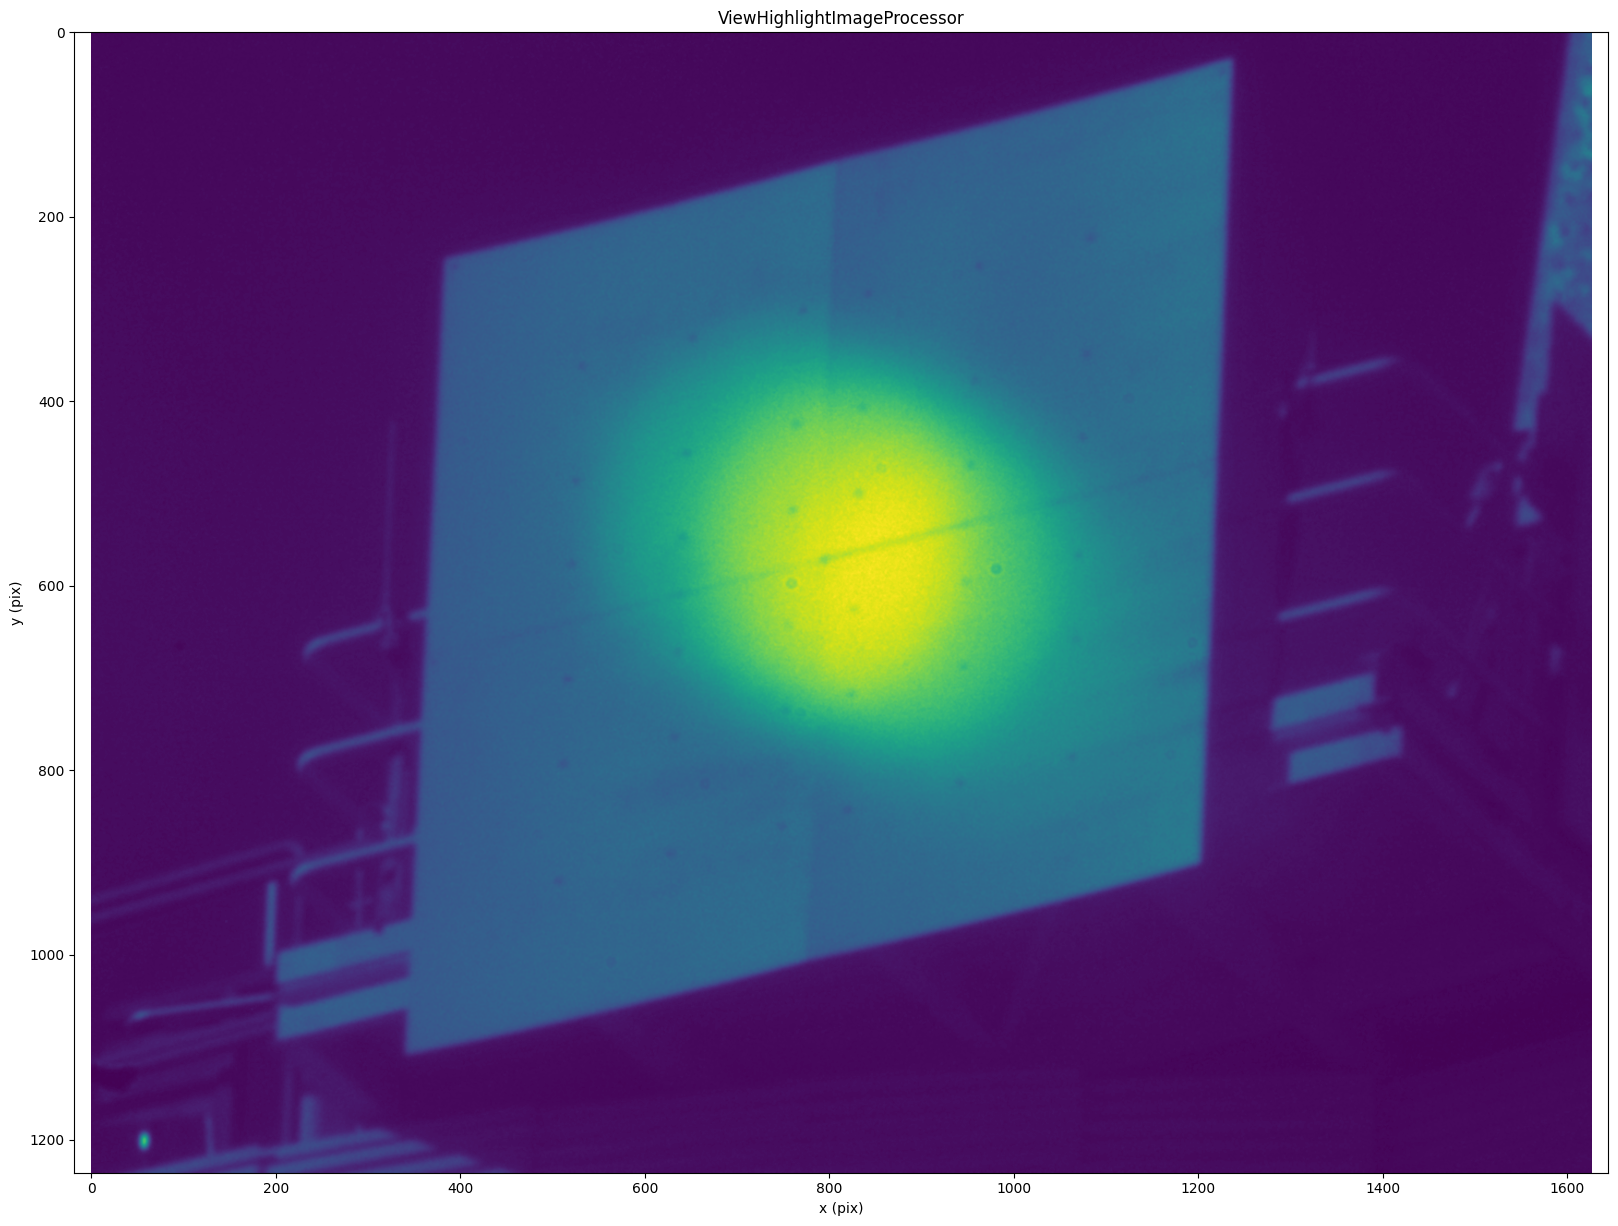

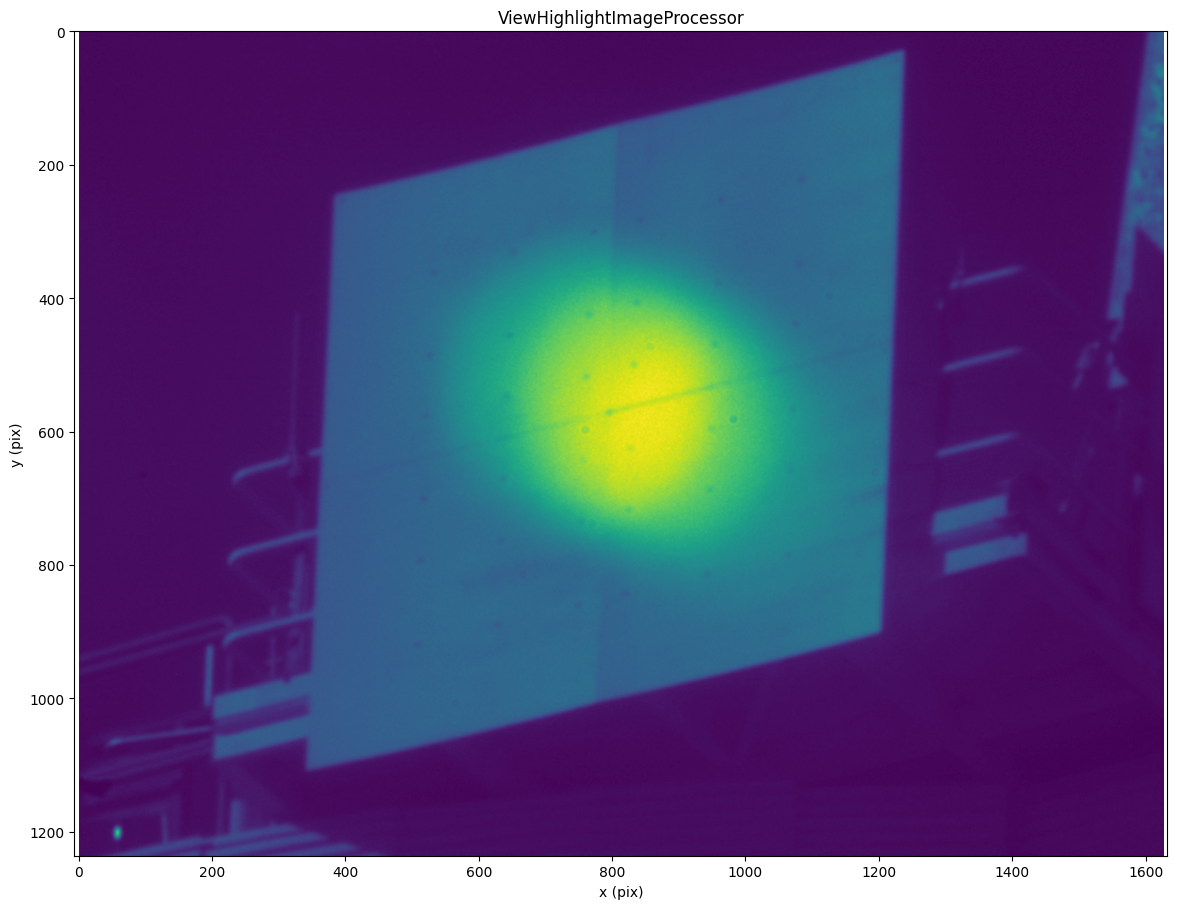

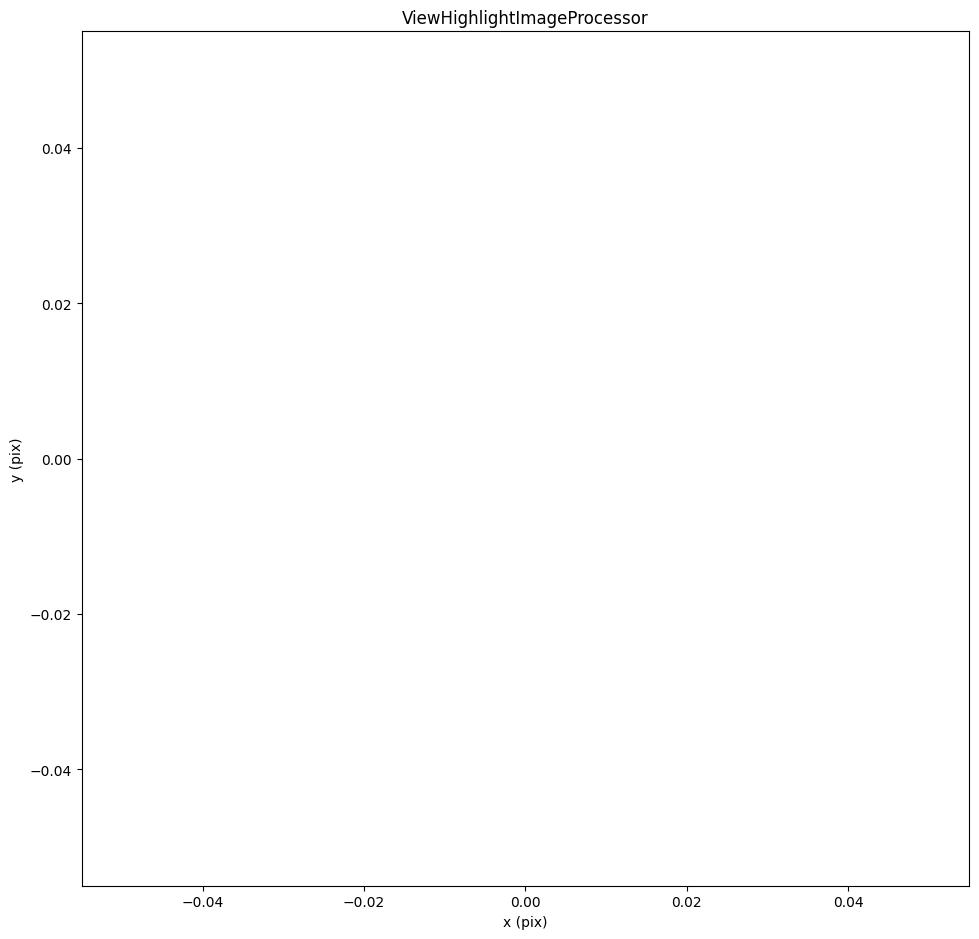

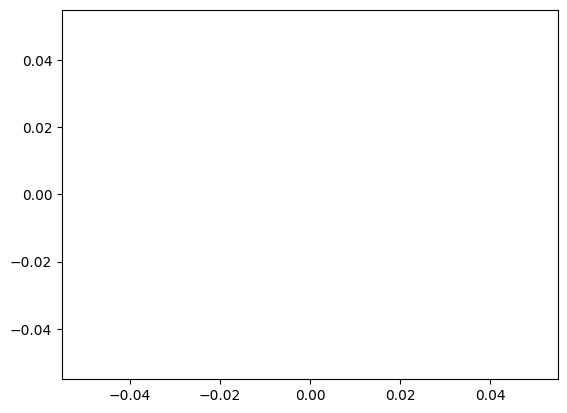


Left: average and blurred on-sun image
Middle: on-sun image after subtracting the no-sun
Right: on-sun image after subtracting the no-sun image and a small brightness value to bring the background to black


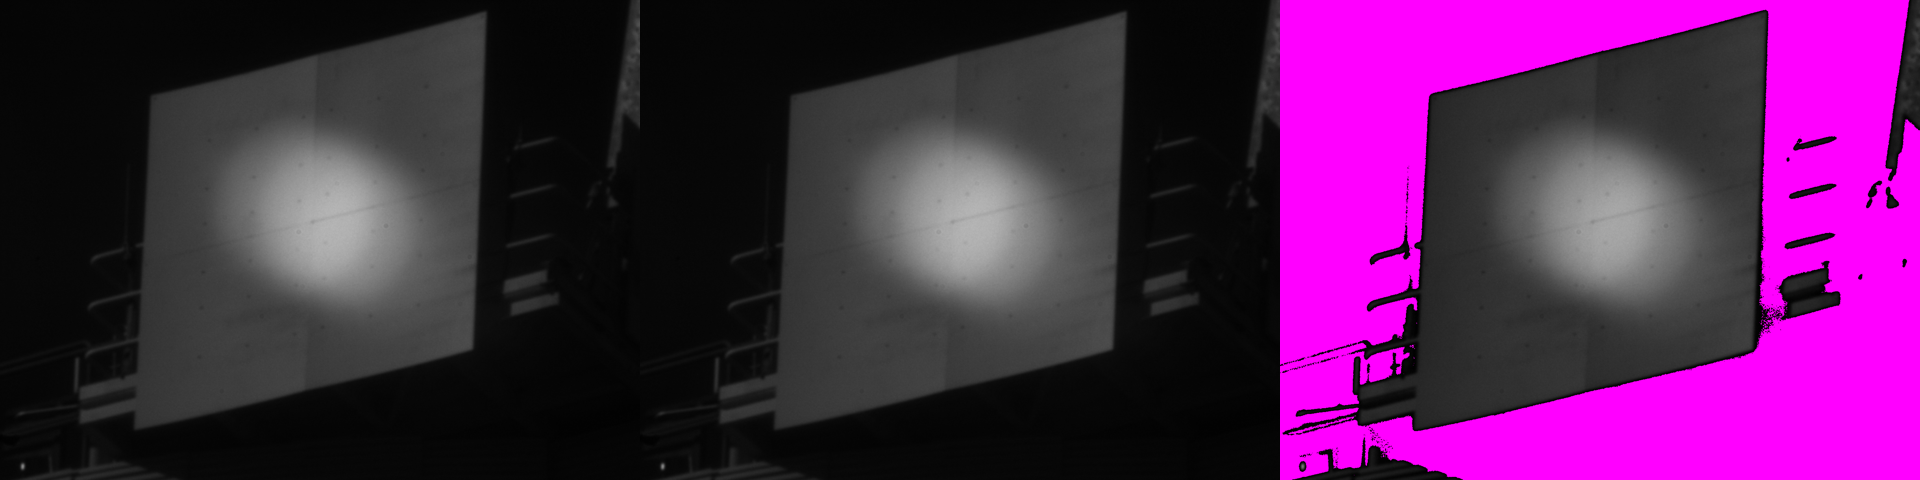

In [6]:
# Experimentally determine the constant value to subtract
# based on running the pipeline a few times
# until the area surrounding the target board is black.
const_sub_val = 13
const_sub_img = np.full_like(np.array(nosun_img), fill_value=const_sub_val)

procs_nsub = {
    "SubNull": NullImageSubtractionImageProcessor(np.array(nosun_img)),
    "VHighlightNsub": ViewHighlightImageProcessor(),
}
procs_nsub_csub = {
    "SubNull": NullImageSubtractionImageProcessor(np.array(nosun_img)),
    "VHighlightNull": ViewHighlightImageProcessor(),
    "ConstSub": NullImageSubtractionImageProcessor(const_sub_img),
    "VHighlightNsubCsub": ViewHighlightImageProcessor(),
}

spot_analysis_nsub = sa.SpotAnalysis("ConstSub", list(procs_nsub.values()))
spot_analysis_nsub.set_primary_images([onsun_img_file])
spot_analysis_nsub_csub = sa.SpotAnalysis("ConstSub", list(procs_nsub_csub.values()))
spot_analysis_nsub_csub.set_primary_images([onsun_img_file])

for processed in spot_analysis_nsub:
    result_nullsub = processed.visualization_images[procs_nsub["VHighlightNsub"]][-1]
    image_nullsub = result_nullsub.to_image()

for processed in spot_analysis_nsub_csub:
    result_null = processed.visualization_images[procs_nsub_csub["VHighlightNull"]][-1]
    image_null = result_null.to_image()
    result_nullsub_constsub = processed.visualization_images[procs_nsub_csub["VHighlightNsubCsub"]][-1]
    image_nullsub_constsub = result_nullsub_constsub.to_image()

# preview the images with values subtracted and absolute blacks highlighted
print(
    "\nLeft: average and blurred on-sun image"
    + "\nMiddle: on-sun image after subtracting the no-sun"
    + "\nRight: on-sun image after subtracting the no-sun image and a small brightness value to bring the background to black"
)
numbering_color = clr.Color.from_generic("White")
numbering_outline_color = clr.Color.from_generic("Black")
ig.ImageGrid(
    (3, 1),
    image_null,
    image_nullsub,
    image_nullsub_constsub,
    subimage_size=(640, 480),
    numbering_color=numbering_color,
    numbering_outline_color=numbering_outline_color
).tile_images()

The following cell builds upon this processing pipeline. In addition to the null and constant subtraction image processors, we now add:

* `PopulationStaticsImageProcessor`: necessary for establishing the brightness range for some visualization image processors
* `MomentsImageProcessor`: computes and attaches the moments to processed images (the first moment is the centroid)
* `HotspotImageProcessor`: an alternative method of locating the center of the spot from the centroid
* `ViewFalseColorImageProcessor`: converts a grayscale image into a rainbow to make it easier to distinguish lights and darks, where darker values are closer to black and lighter values are closer to white
* `ViewAnnotationsImageProcessor`: visualizes all annotations attached to an image. In this situation, that will include annotations from the moments and hotspot image processors.
* `ViewHighlightImageProcessor`: visualizes white pixels as cyan, and black pixels as magenta.
* `ViewCrossSectionImageProcessor`: visualizes the horizontal and vertical cross sections of the image.
* `EnclosedEnergyImageProcessor`: computes the percentage of energy enclosed within a radius of the center of the image.

The visualization image processors have the option for choosing which image they build on. "Primary" would be the main image being processed and is the default. "Visualization" is the last visualization image, so in this case that means that the highlight visualization builds on the false color visualization, and the centroid visualization builds on the highlight visualization.

In [7]:
def get_centroid(operable: sao.SpotAnalysisOperable) -> tuple[int, int]:
    m: manno.MomentsAnnotation = operable.get_fiducials_by_type(manno.MomentsAnnotation)[0]
    return m.centroid.x, m.centroid.y


def get_hotspot(operable: sao.SpotAnalysisOperable) -> tuple[int, int]:
    h: hanno.HotspotAnnotation = operable.get_fiducials_by_type(hanno.HotspotAnnotation)[0]
    return h.origin.x, h.origin.y


# Choose one of the following for choosing the center of the spot:
get_center = get_centroid
# get_center = get_hotspot

procs = {
    "Echo": EchoImageProcessor(),
    "Population": PopulationStatisticsImageProcessor(),
    "SubNull": NullImageSubtractionImageProcessor(np.array(nosun_img)),
    "ConstSub": NullImageSubtractionImageProcessor(const_sub_img),
    "Centroid": MomentsImageProcessor(),
    "Hotspot": HotspotImageProcessor(desired_shape=51),
    "VFalseColr": ViewFalseColorImageProcessor(),
    "VHighlight": ViewHighlightImageProcessor(base_image_selector="Visualization"),
    "VCentroid": ViewAnnotationsImageProcessor(base_image_selector="Visualization"),
    "VCrossSec": ViewCrossSectionImageProcessor(get_center, single_plot=False, y_range=[0, 255]),
    "EncircledEnergy": EnclosedEnergyImageProcessor(
        get_center, enclosed_shape="circle", percentages_of_interest=[0.5, 0.8, 0.9]
    ),
}

We now add a `PowerpointImageProcessor` to the list of image processors. The PowerpointImageProcessor creates a slide deck, with the same number of slides for each resulting processed image. The format for the processors_per_slide parameter is `list( slides )`, the format for each slide is `list( images )`, and the format for images is `tuple( image_processor, title )`.

For the following code, the PowerpointImageProcessor will generate four slides with the following contents:

* Slide 1: results from the four image processors `PopulationStatisticsImageProcessor` (unmodified image), `NullImageSubtractionImageProcessor` (no-sun image subtraction), `NullImageSubtractionImageProcessor` (constant subtraction), and `ViewFalseColorImageProcessor`
* Slide 2: results from the two image processors `ViewHightlightImageProcessor` and `ViewCrossSectionImageProcessor`
* Slide 3: results from the one image processor `ViewAnnotationsImageProcessor`
* Slide 4: results from the two image processors `ViewAnnotationsImageProcessor` and `EnclosedEnergyImageProcessor`

In [8]:
procs["Powerpoint"] = PowerpointImageProcessor(
    save_dir=output_dir,
    save_name=source_img_desc,
    overwrite=True,
    # fmt: off
    processors_per_slide = [
        [ (procs["Population"], "Single Facet Avg"), procs["SubNull"], (procs["ConstSub"], f"Subtract {const_sub_val}"), procs["VFalseColr"] ],
        [ procs["VHighlight"], procs["VCrossSec"] ],
        [ procs["VCentroid"] ],
        [ procs["VCentroid"], procs["EncircledEnergy"] ]
    ],
    # fmt: on
    persistent_save_path = os.path.join(output_dir, "PowerPointFigures")
)


We can now assign the image processors and input images to a spot analysis instance, and process images until all input images have been exhausted.

Processing image Single_NSTTF_Facet_0900_onsun_avg.png
In HotspotImageProcessor._execute(): can't import scikit-image (ModuleNotFoundError("No module named 'skimage'")), and so can't determine if the matching region is continuous


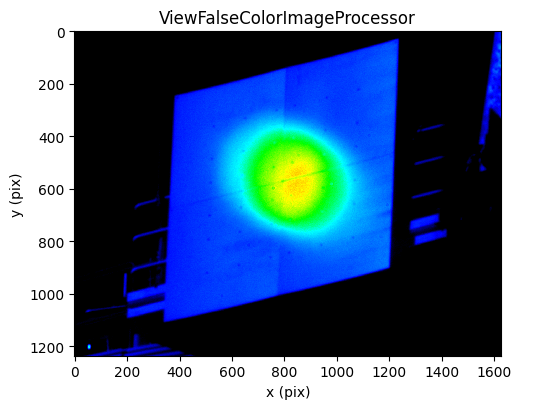

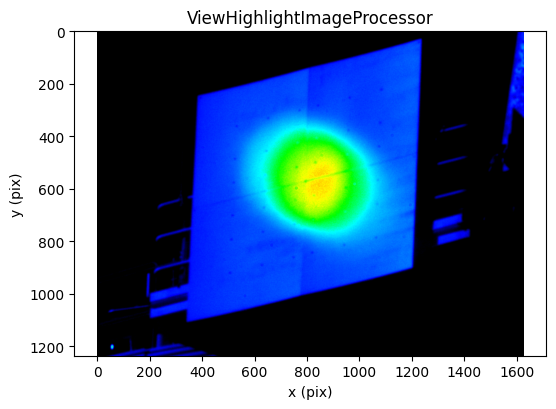

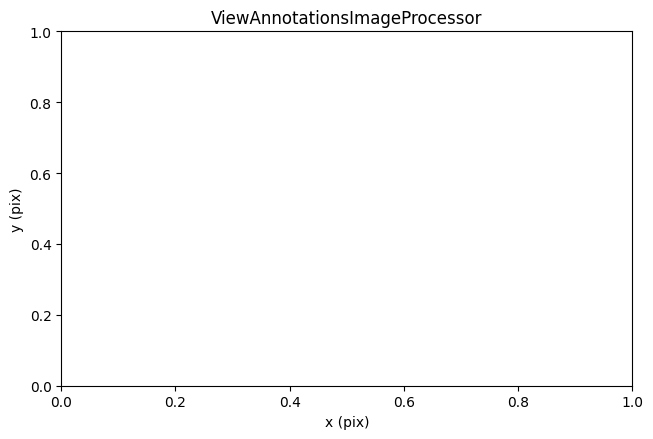

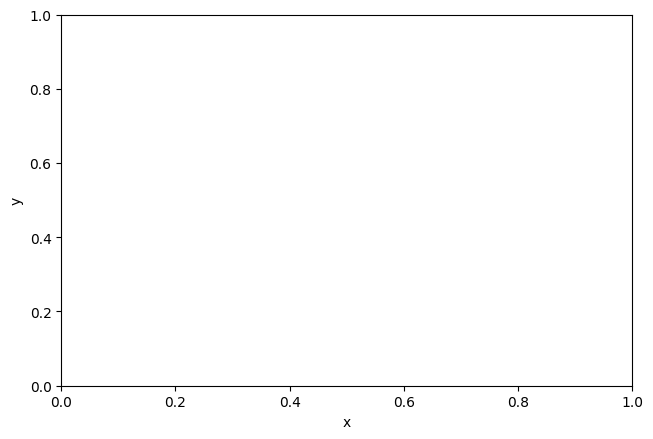

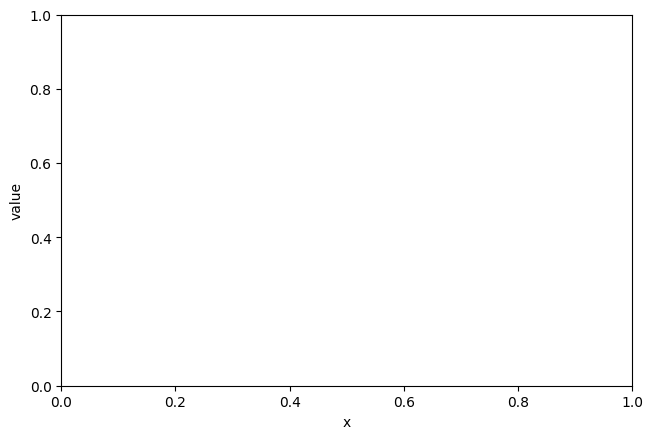

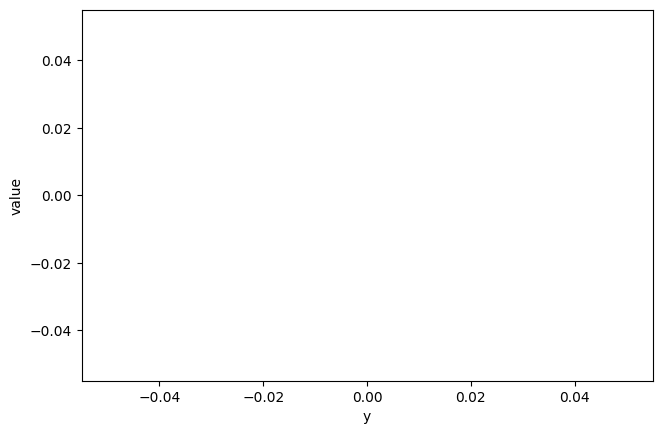

C:\Users\rcbrost\Code\OpenCSP\opencsp\common\lib\render\View3d.py:319: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  self.axis.arrow(


Percentage of interest 0.5 is at radius 283
Percentage of interest 0.8 is at radius 421
Percentage of interest 0.9 is at radius 494


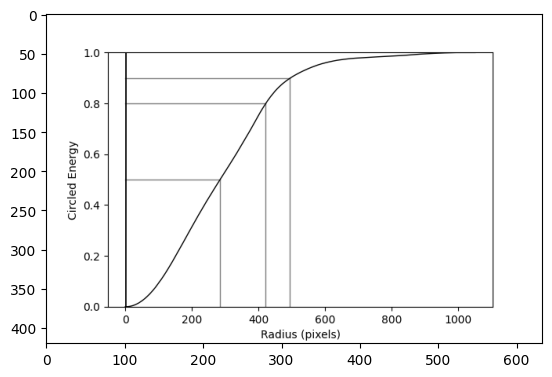

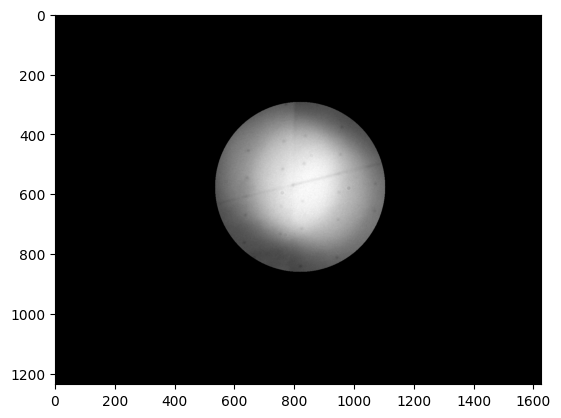

Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\3_37.png
Saving persistent image to:    C:\ctemp\OpenCSP_example_data\enclosed_energy\output\HeliostatsSpotSize\3_Post\PowerPointFigures\3_37.png
Saving persistent metadata to: C:\ctemp\OpenCSP_example_data\enclosed_energy\output\HeliostatsSpotSize\3_Post\PowerPointFigures\3_37.txt
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\3_38.png
Saving persistent image to:    C:\ctemp\OpenCSP_example_data\enclosed_energy\output\HeliostatsSpotSize\3_Post\PowerPointFigures\3_38.png
Saving persistent metadata to: C:\ctemp\OpenCSP_example_data\enclosed_energy\output\HeliostatsSpotSize\3_Post\PowerPointFigures\3_38.txt
Saving temporary image to:     C:\Users\rcbrost\AppData\Local\opencsp\scratch\tmp\PowerpointImage\images\tmp\3_39.png
Saving persistent image to:    C:\ctemp\OpenCSP_example_data\enclosed_energy\output\HeliostatsSpot

In [9]:
# create the image processing spot analysis pipeline
spot_analysis = sa.SpotAnalysis("EncircledEnergy", list(procs.values()), save_dir=output_dir, save_overwrite=True)
spot_analysis.set_primary_images([onsun_img_file])

# retrieve processed images until there are no more input images
for processed in spot_analysis:
    pass

Results
-------

Now that processing is all done we will print out the path to the generated powerpoint deck, and the pixel radius that envelopes the percentage of interest (poi) total enclosed energy.

In [10]:
# Get the results
print(f"The Powerpoint slide deck is saved to {procs['Powerpoint'].dest_path_name_ext}")

all_processors_notes = processed.image_processor_notes
enclosed_energy_notes = list(filter(lambda notes: "Enclosed" in notes[0], all_processors_notes))[0]
processor_name, data = enclosed_energy_notes
percentages_of_interest, enclosed_energy_by_radius = data

for poi in percentages_of_interest:
    print(f"Radius for {int(poi*100)}% encircled energy: {percentages_of_interest[poi]}px")

The Powerpoint slide deck is saved to C:\ctemp\OpenCSP_example_data\enclosed_energy\output\HeliostatsSpotSize\3_Post\Single_NSTTF_Facet_0900.pptx
Radius for 50% encircled energy: 283px
Radius for 80% encircled energy: 421px
Radius for 90% encircled energy: 494px
